# Fault sweep — grounding impedance & reduction factor per bus

When the fault location is not known a priori, a common analysis is to
**sweep the fault across every candidate bus** and read off the resulting
grounding impedance `Z_G` and reduction factor `r` at each fault site.
This notebook demonstrates that workflow on a 10-bus MV cable line and
visualises the results with the helper `Network.res_all_impedances()`.

Steps:

1. Build a 10-bus MV cable line at five frequencies (50, 250, 350, 450, 550 Hz).
2. Create one fault per bus, plus a single source at `bus1`.
3. Loop `gi.run_fault` over every fault.
4. Read the long-format DataFrame returned by `res_all_impedances()`.
5. Plot `|Z_G|(fault_bus)` and `r(fault_bus)` per frequency.


In [1]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt

import groundinsight as gi
from groundinsight.models.core_models import BusType, BranchType

print('groundinsight', gi.__version__)


groundinsight 0.4.0


## 1. Bus and branch types

Generic MV cable / overhead-line types based on the per-length values used
in the reduction-factor reference cases. The cable has full mutual coupling
(`Im(Z_self) = Im(Z_mutual)`), so the analytical 50 Hz reduction factor on a
single cable section is `r = |1 - Z_mutual / Z_self| = 0.3846`. All formulas
scale with frequency through `f` and with soil resistivity through `rho`.


In [2]:
rho = 100.0  # specific earth resistivity in Ohm·m

bus_type = BusType(
    name='BusUnit',
    description='Unit-like bus impedance, dominated by cable shield path',
    system_type='Grounded',
    voltage_level=20.0,
    impedance_formula='rho * 0 + 1.0 + I * f * 0',
)

cable_type = BranchType(
    name='MSCable',
    description='MV cable with shield (constant L, M)',
    grounding_conductor=True,
    self_impedance_formula='(0.25 + I * 0.6 * f / 50) * l',
    mutual_impedance_formula='(0.0  + I * 0.6 * f / 50) * l',
)


## 2. Build a 10-bus line

Source at `bus1`, faults at every bus. Each fault re-uses the same source.
`gi.run_fault` is called once per fault — the solver caches the network
topology, so the per-call cost is the linear solve only.


In [3]:
FREQS = [50.0, 250.0, 350.0, 450.0, 550.0]
N_BUS = 10
LINE_LENGTH_KM = 0.5  # km per section

net = gi.create_network(name='FaultSweep', frequencies=FREQS,
                         description='10-bus MV cable line, fault sweep demo')

for i in range(1, N_BUS + 1):
    gi.create_bus(name=f'bus{i:02d}', type=bus_type, network=net,
                  specific_earth_resistance=rho)

for i in range(1, N_BUS):
    gi.create_branch(
        name=f'b{i:02d}_{i+1:02d}',
        type=cable_type,
        from_bus=f'bus{i:02d}',
        to_bus=f'bus{i+1:02d}',
        length=LINE_LENGTH_KM,
        specific_earth_resistance=rho,
        network=net,
    )

source_values = {f: 1000.0 for f in FREQS}     # 1 kA injection at every freq
fault_scaling = {f: 1.0 for f in FREQS}        # full scaling at every freq

gi.create_source(name='src', bus='bus01', values=source_values, network=net)
for i in range(1, N_BUS + 1):
    gi.create_fault(name=f'f{i:02d}', bus=f'bus{i:02d}',
                    scalings=fault_scaling, network=net)

gi.create_paths(network=net)
print(f'{len(net.buses)} buses, {len(net.branches)} branches, '
      f'{len(net.faults)} faults, {len(net.frequencies)} frequencies')


10 buses, 9 branches, 10 faults, 5 frequencies


## 3. Run the sweep

One `gi.run_fault` call per fault location. The faults at `bus01` (the
source bus) collapse into the source itself, so the grounding impedance
and reduction factor are not defined there — `res_all_impedances` emits
`null` for that fault.


In [4]:
for i in range(1, N_BUS + 1):
    gi.run_fault(net, fault_name=f'f{i:02d}')

impedance_df = net.res_all_impedances()
impedance_df.head()


fault_name,fault_bus,frequency_Hz,grounding_impedance_Ohm,grounding_impedance_deg,reduction_factor
str,str,f64,f64,f64,f64
"""f01""","""bus01""",50.0,null,null,null
"""f01""","""bus01""",250.0,null,null,null
"""f01""","""bus01""",350.0,null,null,null
"""f01""","""bus01""",450.0,null,null,null
"""f01""","""bus01""",550.0,null,null,null


## 4. Slice and pivot

`res_all_impedances()` returns one row per (fault, frequency). To plot
the sweep we pivot it to one row per fault bus and one column per
frequency — once for `|Z_G|` and once for `r`.


In [5]:
# Drop rows with null Z_G (fault sitting on the source bus)
clean = impedance_df.drop_nulls(subset=['grounding_impedance_Ohm'])

zg_wide = clean.pivot(
    values='grounding_impedance_Ohm',
    index='fault_bus',
    on='frequency_Hz',
).sort('fault_bus')

rf_wide = clean.pivot(
    values='reduction_factor',
    index='fault_bus',
    on='frequency_Hz',
).sort('fault_bus')

print('--- |Z_G| per fault bus ---')
print(zg_wide)
print('\n--- reduction factor per fault bus ---')
print(rf_wide)


--- |Z_G| per fault bus ---
shape: (9, 6)
┌───────────┬──────────┬──────────┬──────────┬──────────┬──────────┐
│ fault_bus ┆ 50.0     ┆ 250.0    ┆ 350.0    ┆ 450.0    ┆ 550.0    │
│ ---       ┆ ---      ┆ ---      ┆ ---      ┆ ---      ┆ ---      │
│ str       ┆ f64      ┆ f64      ┆ f64      ┆ f64      ┆ f64      │
╞═══════════╪══════════╪══════════╪══════════╪══════════╪══════════╡
│ bus02     ┆ 0.090809 ┆ 0.451909 ┆ 0.576526 ┆ 0.669021 ┆ 0.737593 │
│ bus03     ┆ 0.177151 ┆ 0.612865 ┆ 0.714742 ┆ 0.781937 ┆ 0.828683 │
│ bus04     ┆ 0.235997 ┆ 0.623673 ┆ 0.703117 ┆ 0.760351 ┆ 0.804045 │
│ bus05     ┆ 0.268544 ┆ 0.603528 ┆ 0.682151 ┆ 0.743569 ┆ 0.791699 │
│ bus06     ┆ 0.282068 ┆ 0.590123 ┆ 0.674369 ┆ 0.739828 ┆ 0.790094 │
│ bus07     ┆ 0.285395 ┆ 0.585854 ┆ 0.673662 ┆ 0.740086 ┆ 0.79048  │
│ bus08     ┆ 0.293048 ┆ 0.580651 ┆ 0.673108 ┆ 0.740599 ┆ 0.791028 │
│ bus09     ┆ 0.335259 ┆ 0.562531 ┆ 0.65283  ┆ 0.724004 ┆ 0.778726 │
│ bus10     ┆ 0.459211 ┆ 0.767244 ┆ 0.832303 ┆ 0.874619 ┆ 0.9

## 5. Visualisation

Grouped bar plots: one bar per frequency at each fault bus.


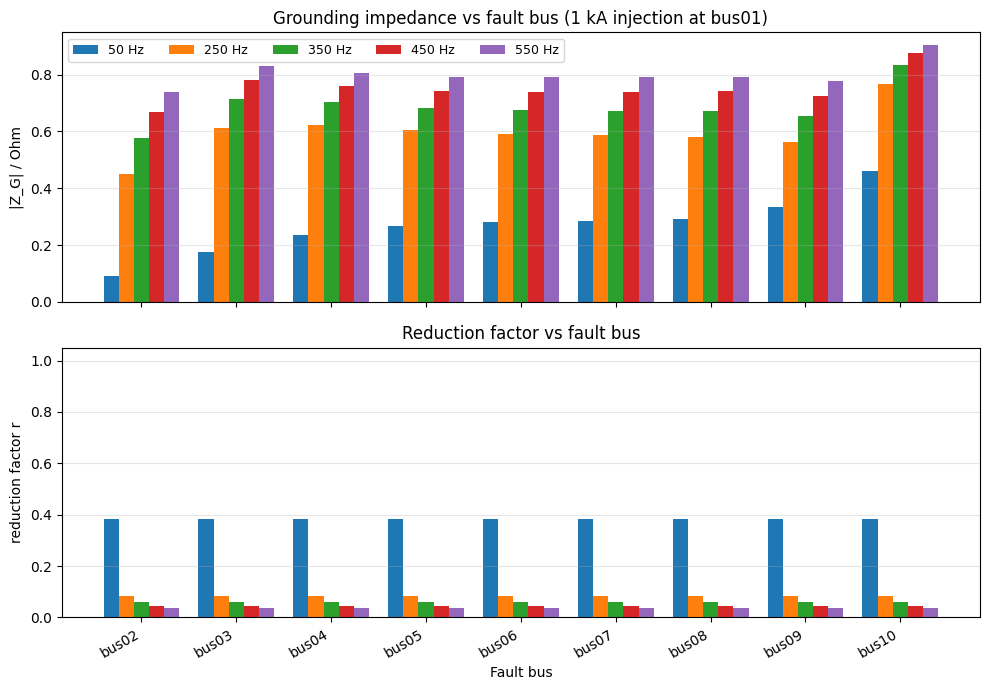

In [6]:
fault_buses = zg_wide['fault_bus'].to_list()
x = np.arange(len(fault_buses))
width = 0.16

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

ax = axes[0]
for k, f in enumerate(FREQS):
    col = str(f)
    if col not in zg_wide.columns:
        continue
    ax.bar(x + (k - (len(FREQS) - 1) / 2) * width,
           zg_wide[col].to_list(),
           width=width,
           label=f'{int(f)} Hz')
ax.set_ylabel('|Z_G| / Ohm')
ax.set_title('Grounding impedance vs fault bus (1 kA injection at bus01)')
ax.grid(True, axis='y', alpha=0.3)
ax.legend(ncol=len(FREQS), loc='upper left', fontsize=9)

ax = axes[1]
for k, f in enumerate(FREQS):
    col = str(f)
    if col not in rf_wide.columns:
        continue
    ax.bar(x + (k - (len(FREQS) - 1) / 2) * width,
           rf_wide[col].to_list(),
           width=width,
           label=f'{int(f)} Hz')
ax.set_xlabel('Fault bus')
ax.set_ylabel('reduction factor r')
ax.set_title('Reduction factor vs fault bus')
ax.set_xticks(x)
ax.set_xticklabels(fault_buses, rotation=30, ha='right')
ax.grid(True, axis='y', alpha=0.3)
ax.set_ylim(0, 1.05)

fig.tight_layout()
plt.show()


## 6. Profile interpretation

Two things worth noting on the resulting plots:

* **`|Z_G|` grows with distance from the source.** The farther the fault
  is from the source bus, the more cable shield is in the return path —
  the equivalent impedance seen by the injected current goes up.
* **`r` decreases with frequency.** The shield inductance dominates the
  shield path at higher frequencies, so the mutual coupling cancels more
  of the self impedance. For this cable type `r` drops from ~0.38 at
  50 Hz to well below 0.05 at 550 Hz.

The wide DataFrames `zg_wide` / `rf_wide` can be exported to CSV or
Excel directly via `polars.DataFrame.write_csv` / `write_excel` for
downstream reporting.
